In [1]:
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

I0000 00:00:1789218123.739295   47935 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789218124.057011   47935 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789218125.537297   47935 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast,
    Flatten
)

from tensorflow.keras.regularizers import l2
from PIL import Image

In [3]:
with open("all.json", "r") as file:
    data = json.load(file)

In [5]:
X = []
y = []

In [6]:
for category in data:
    for image in data[category]:
        img = Image.open(f"./all/{image}")
        img = img.convert("RGB")
        img = img.resize((224, 224))
        img_array = np.array(img)
        X.append(img_array)
        y.append(category)

/home/shashi/miniconda3/envs/tensorflow-gpu/lib/python3.11/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [7]:
X = np.array(X)
y = np.array(y)

In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [11]:
# First split: 80% training+validation, 20% testing
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42,
    stratify=y_temp
)

print("Training images:", X_train.shape)
print("Validation images:", X_val.shape)
print("Testing images:", X_test.shape)

print("\nNumber of classes:", len(encoder.classes_))
print("Classes:", encoder.classes_)

Training images: (7680, 224, 224, 3)
Validation images: (1920, 224, 224, 3)
Testing images: (2400, 224, 224, 3)

Number of classes: 2
Classes: [0 1]


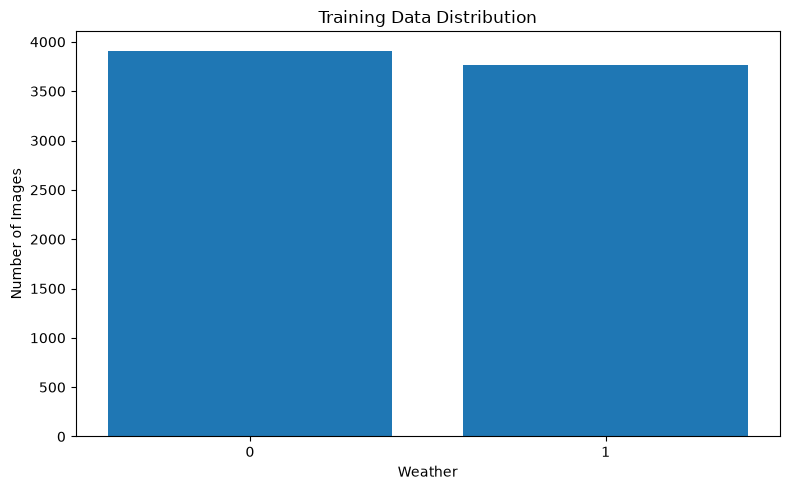

In [12]:
classes, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.xlabel("Weather")
plt.ylabel("Number of Images")
plt.title("Training Data Distribution")
plt.tight_layout()
plt.xticks(classes)
plt.show()

In [13]:
num_classes = len(encoder.classes_)

model = Sequential([
    
    Input(shape=(224, 224, 3)),
    
    RandomFlip("horizontal"),
    
    RandomRotation(0.1),
    
    RandomZoom(0.1),
    
    RandomContrast(0.1),
    
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),
    
    GlobalAveragePooling2D(),
    
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.0001)
    ),
    
    Dropout(0.5),

    Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()

I0000 00:00:1789218380.767059   47935 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3617 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,490 (1.62 MB)

 Trainable params: 422,530 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.000001
)

checkpoint = ModelCheckpoint(
    "best_weather_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    
    validation_data=(
        X_val,
        y_val
    ),
    
    epochs=30,
    
    batch_size=32,
    
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],
    
    verbose=1
)

Epoch 1/30


I0000 00:00:1789218411.037768   48342 cuda_dnn.cc:461] Loaded cuDNN version 92600


240/240 ━━━━━━━━━━━━━━━━━━━━ 53s 186ms/step - accuracy: 0.7161 - loss: 0.6110 - val_accuracy: 0.7703 - val_loss: 0.5529 - learning_rate: 3.0000e-04
Epoch 2/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 42s 173ms/step - accuracy: 0.7854 - loss: 0.5087 - val_accuracy: 0.8141 - val_loss: 0.4490 - learning_rate: 3.0000e-04
Epoch 3/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 41s 172ms/step - accuracy: 0.8089 - loss: 0.4671 - val_accuracy: 0.8099 - val_loss: 0.4779 - learning_rate: 3.0000e-04
Epoch 4/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 42s 173ms/step - accuracy: 0.8253 - loss: 0.4368 - val_accuracy: 0.8146 - val_loss: 0.4919 - learning_rate: 3.0000e-04
Epoch 5/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 42s 174ms/step - accuracy: 0.8516 - loss: 0.3932 - val_accuracy: 0.8620 - val_loss: 0.3634 - learning_rate: 1.5000e-04
Epoch 6/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 82s 173ms/step - accuracy: 0.8622 - loss: 0.3694 - val_accuracy: 0.8708 - val_loss: 0.3336 - learning_rate: 1.5000e-04
Epoch 7/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 42s 173ms/step - 

In [17]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nTesting Loss    :", test_loss)
print("Testing Accuracy:", test_accuracy)


Testing Loss    : 0.21009249985218048
Testing Accuracy: 0.9412500262260437


In [18]:
y_pred_probability = model.predict(X_test)
y_pred = np.argmax(y_pred_probability, axis=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step


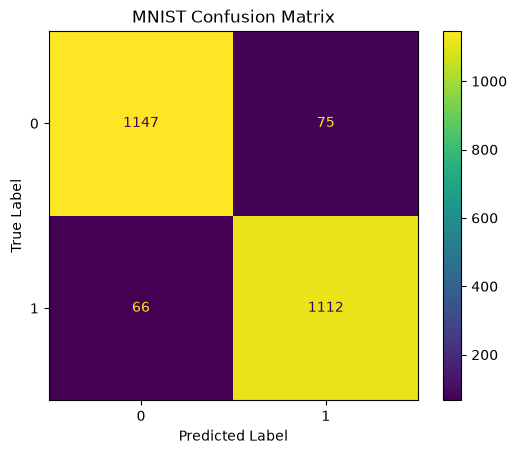

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")
plt.show()

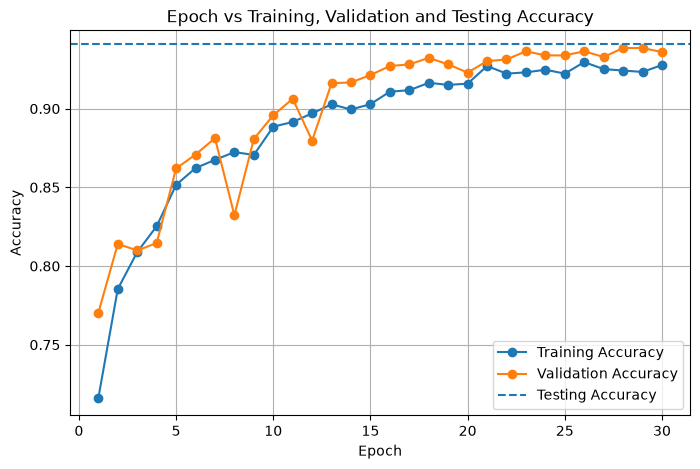

In [23]:
epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axhline(
    test_accuracy,
    linestyle="--",
    label="Testing Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Epoch vs Training, Validation and Testing Accuracy")
plt.legend()
plt.grid(True)
plt.show()

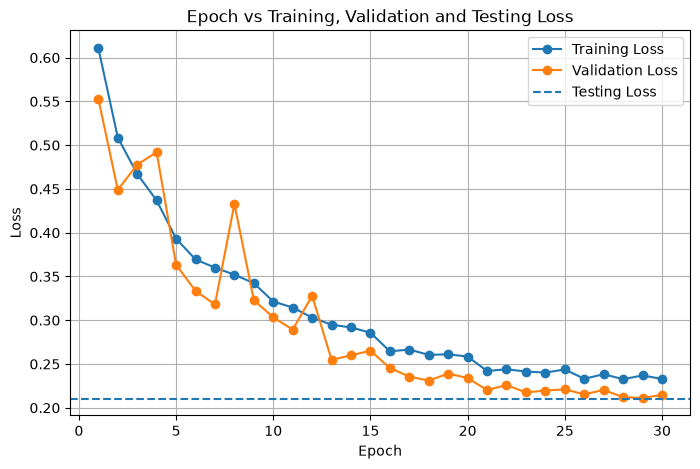

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axhline(
    test_loss,
    linestyle="--",
    label="Testing Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Training, Validation and Testing Loss")
plt.legend()
plt.grid(True)
plt.show()